# Variational Autoencoder with PyTorch 

In [126]:
pip install torch torchvision

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.2 -> 24.3.1
[notice] To update, run: C:\Users\BOUKA\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.10_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


## Imports 

In [127]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load in 

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
# Input data files are available in the "../input/" directory.
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory
import os
for dirname, _, filenames in os.walk('/inputs'):
    for filename in filenames:
        print(os.path.join(dirname, filename))
        
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch import nn, optim
from torch.autograd import Variable
from sklearn.decomposition import PCA

import pandas as pd
import numpy as np
from sklearn import preprocessing

# Any results you write to the current directory are saved as output.

In [128]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
device

device(type='cpu')

## Get a quick view of the data 

In [129]:

def read_data_file(file_path):
    column_names = []
    data_start_index = 0
    with open(file_path, 'r') as file:
        for index, line in enumerate(file):
            if line.startswith('@inputs'):
                inputs = line.strip().split(' ', 1)[1]
                column_names.extend(inputs.split(', '))
            elif line.startswith('@output'):
                output = line.strip().split(' ', 1)[1]
                column_names.append(output)
            elif line.strip().lower() == '@data':
                data_start_index = index + 1
                break

    # Read the data into a DataFrame using the extracted column names and starting index
    data = pd.read_csv(file_path, skiprows=data_start_index, header=None, names=column_names)
    return data

# Define the path to your .data file
file_path = r'C:\Users\BOUKA\Downloads\VAE-Code\inputs\new-thyroid1\new-thyroid1.dat' 

# Call the function and get the DataFrame
dataframe = read_data_file(file_path)

# Display the first few rows of the DataFrame
dataframe.head()

,T3resin,Thyroxin,Triiodothyronine,Thyroidstimulating,TSH_value,Class
0,105,7.3,1.5,1.5,-0.1,negative
1,67,23.3,7.4,1.8,-0.6,positive
2,111,8.4,1.5,0.8,1.2,negative
3,89,14.3,4.1,0.5,0.2,positive
4,105,9.5,1.8,1.6,3.6,negative


## Process datasets

In [130]:
import matplotlib.pyplot as plt
import seaborn as sns

In [131]:
dataframe['Class'].value_counts()

Class
 negative    180
 positive     35
Name: count, dtype: int64

In [132]:
dataframe['Class'].replace("negative", 0, inplace=True)
dataframe['Class'].replace("positive", 1, inplace=True)

In [133]:
dataframe['Class'].value_counts()

Class
 negative    180
 positive     35
Name: count, dtype: int64

In [134]:
dataframe = dataframe.rename(columns={"Class": "Outcome"})

In [135]:
dataframe['Outcome'].value_counts()

Outcome
 negative    180
 positive     35
Name: count, dtype: int64

In [136]:
dataframe.head()

,T3resin,Thyroxin,Triiodothyronine,Thyroidstimulating,TSH_value,Outcome
0,105,7.3,1.5,1.5,-0.1,negative
1,67,23.3,7.4,1.8,-0.6,positive
2,111,8.4,1.5,0.8,1.2,negative
3,89,14.3,4.1,0.5,0.2,positive
4,105,9.5,1.8,1.6,3.6,negative


In [137]:
dataframe['Outcome'].convert_dtypes()

0       negative
1       positive
2       negative
3       positive
4       negative
         ...    
210     negative
211     negative
212     negative
213     positive
214     negative
Name: Outcome, Length: 215, dtype: string

In [138]:
dataframe['Outcome'].value_counts()

Outcome
 negative    180
 positive     35
Name: count, dtype: int64

In [139]:
dataframe = dataframe.astype({'Outcome': 'str'},)

In [140]:
dataframe['Outcome'].unique()

array([' negative', ' positive'], dtype=object)

In [141]:
mappings = {' negative': 0, ' positive':1}
dataframe['Outcome'] = dataframe['Outcome'].map(mappings)

In [142]:
dataframe.head()

,T3resin,Thyroxin,Triiodothyronine,Thyroidstimulating,TSH_value,Outcome
0,105,7.3,1.5,1.5,-0.1,0
1,67,23.3,7.4,1.8,-0.6,1
2,111,8.4,1.5,0.8,1.2,0
3,89,14.3,4.1,0.5,0.2,1
4,105,9.5,1.8,1.6,3.6,0


#### Null Values

<Axes: >

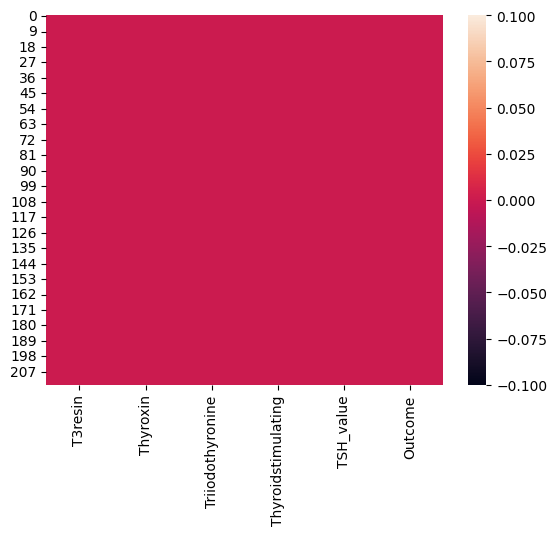

In [144]:
sns.heatmap(dataframe.isnull())

In [145]:
dataframe.isnull().sum()

T3resin               0
Thyroxin              0
Triiodothyronine      0
Thyroidstimulating    0
TSH_value             0
Outcome               0
dtype: int64

#### Cleansing the data: removing outliers

### Visualizations

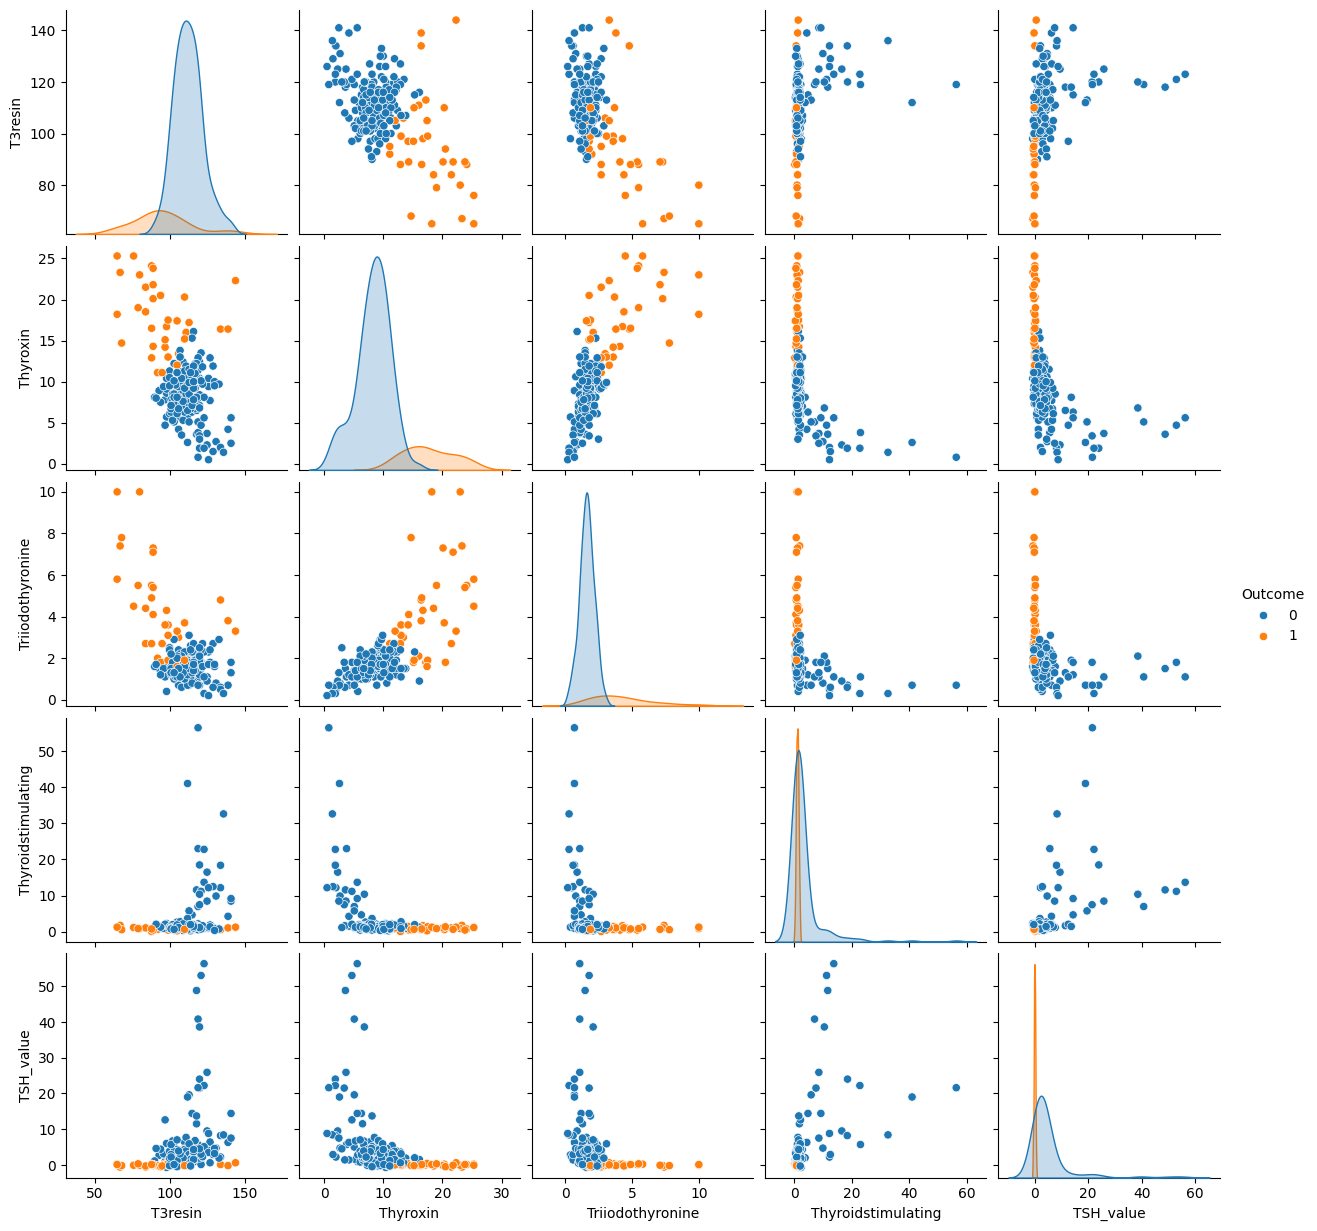

In [146]:
sns.pairplot(data=dataframe, hue='Outcome')

#### Spearman Rank Correlation

In [147]:
dataframe.head()

,T3resin,Thyroxin,Triiodothyronine,Thyroidstimulating,TSH_value,Outcome
0,105,7.3,1.5,1.5,-0.1,0
1,67,23.3,7.4,1.8,-0.6,1
2,111,8.4,1.5,0.8,1.2,0
3,89,14.3,4.1,0.5,0.2,1
4,105,9.5,1.8,1.6,3.6,0


<Axes: >

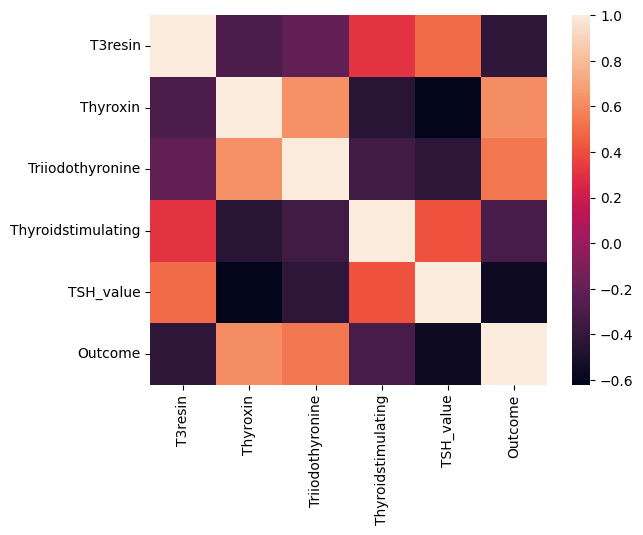

In [148]:
corr = dataframe.corr(method="spearman")
sns.heatmap(corr,annot=False)

* We drop outlier values using **IQR(Interquartile Range Method)**

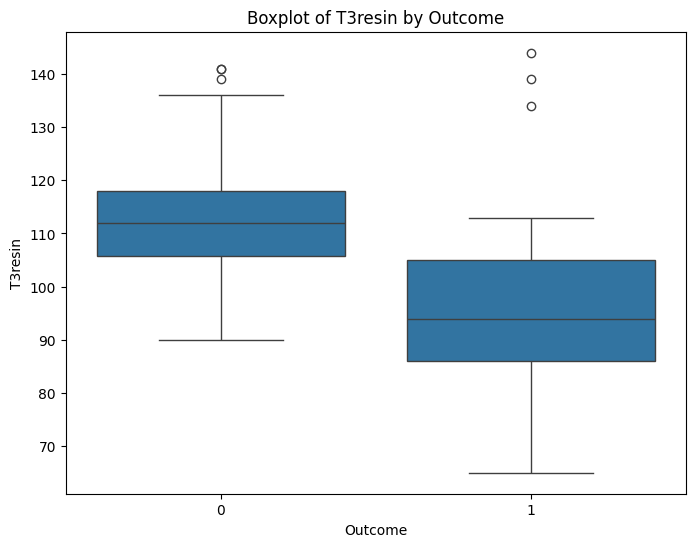

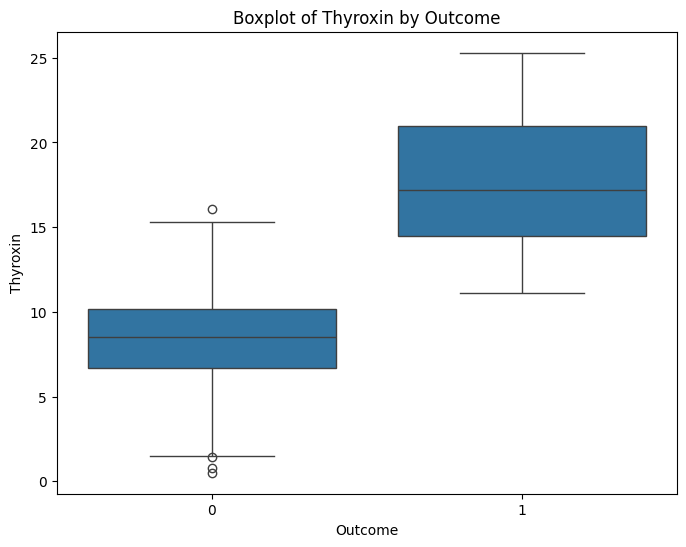

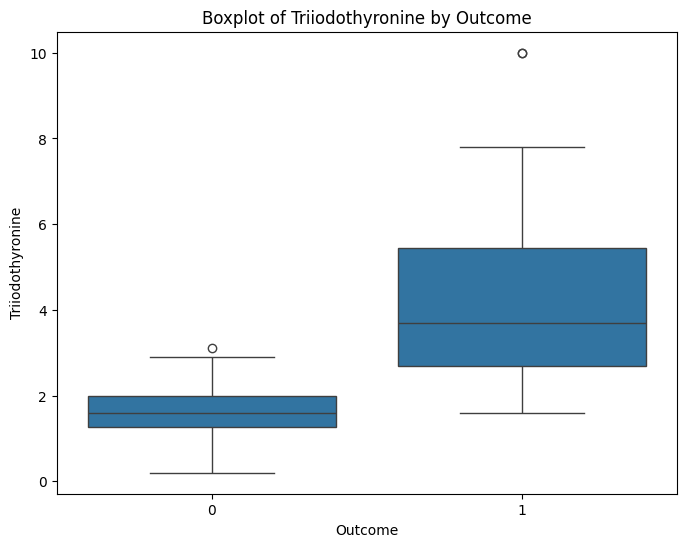

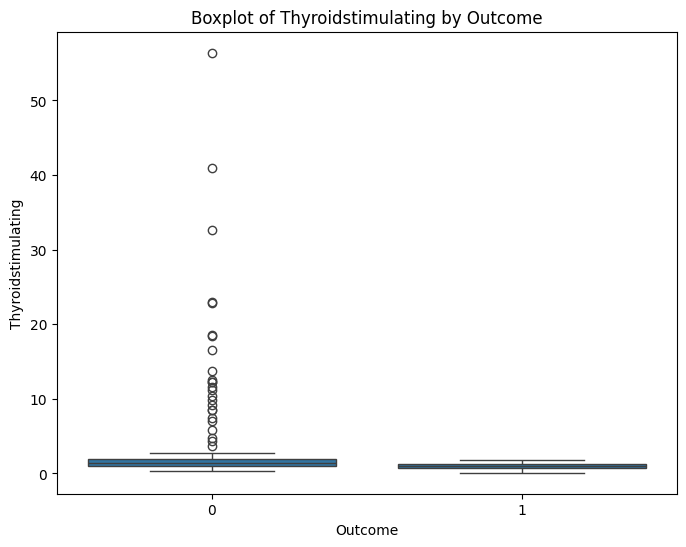

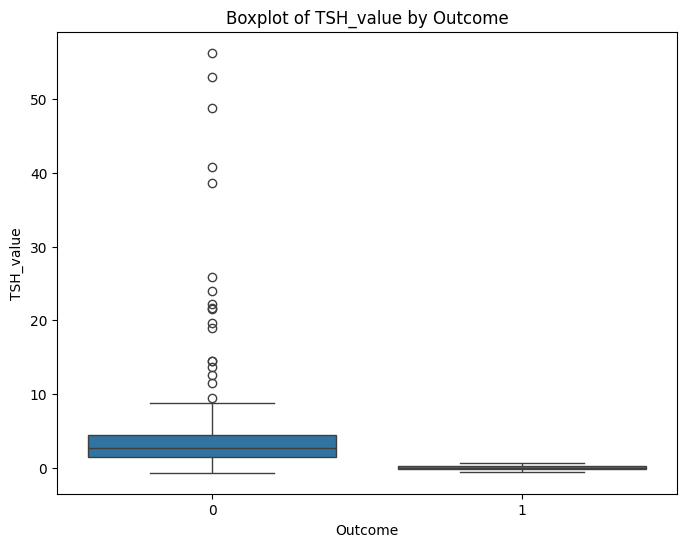

In [150]:
cols = [col for col in dataframe.columns if col!="Outcome"]
for col in cols:
        plt.figure(figsize=(8, 6))
        sns.boxplot(data=dataframe, x="Outcome", y=col)
        plt.title(f'Boxplot of {col} by Outcome')
        plt.show()

In [151]:
def removeOutlier(col):
    sorted(col)
    quant1, quant2 = col.quantile([0.25, 0.75])
    IQR = quant2 - quant1
    lowerRange = quant1 - (1.5 * IQR)
    upperRange = quant2 + (1.5 * IQR)
    return lowerRange, upperRange

In [152]:
dataframe.describe()

,T3resin,Thyroxin,Triiodothyronine,Thyroidstimulating,TSH_value,Outcome
count,215.000000,215.000000,215.000000,215.000000,215.000000,215.000000
mean,109.595349,9.804651,2.050233,2.880000,4.199070,0.162791
std,13.145447,4.697362,1.419486,6.118031,8.070519,0.370036
min,65.000000,0.500000,0.200000,0.100000,-0.700000,0.000000
25%,103.000000,7.100000,1.350000,1.000000,0.550000,0.000000
50%,110.000000,9.200000,1.700000,1.300000,2.000000,0.000000
75%,117.500000,11.300000,2.200000,1.700000,4.100000,0.000000
max,144.000000,25.300000,10.000000,56.400000,56.300000,1.000000


In [155]:
for col in cols:
    lowScore, highScore = removeOutlier(dataframe[col])
    print(f"Column: {col}, Lower Bound: {lowScore}, Upper Bound: {highScore}")
    dataframe[col] = np.where(dataframe[col]>highScore, highScore, dataframe[col])
    dataframe[col] = np.where(dataframe[col]<lowScore, lowScore, dataframe[col])

Column: T3resin, Lower Bound: 81.25, Upper Bound: 139.25
Column: Thyroxin, Lower Bound: 0.799999999999998, Upper Bound: 17.6
Column: Triiodothyronine, Lower Bound: 0.07499999999999996, Upper Bound: 3.4750000000000005
Column: Thyroidstimulating, Lower Bound: -0.04999999999999982, Upper Bound: 2.75
Column: TSH_value, Lower Bound: -4.7749999999999995, Upper Bound: 9.424999999999999


* **Check if the outliers are handled**

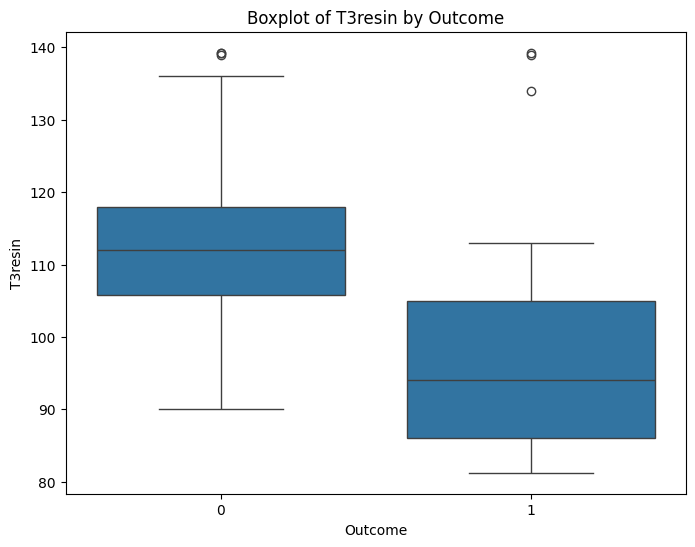

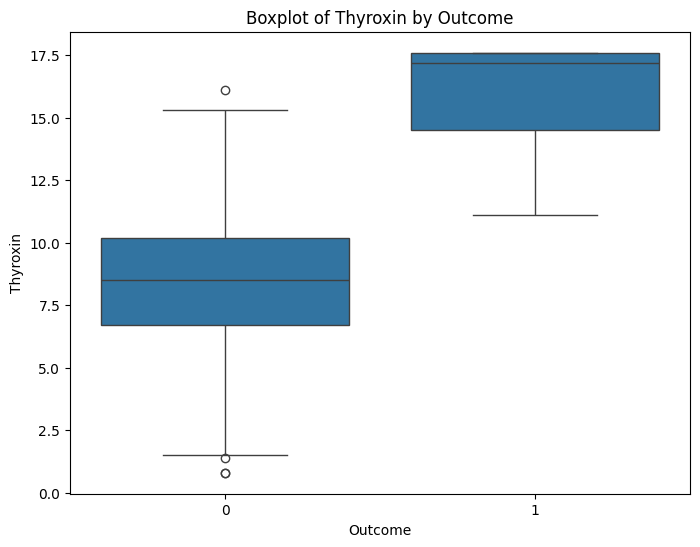

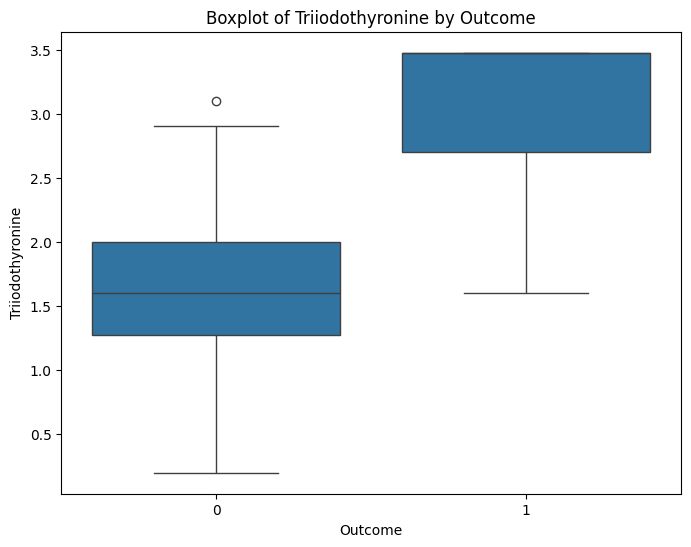

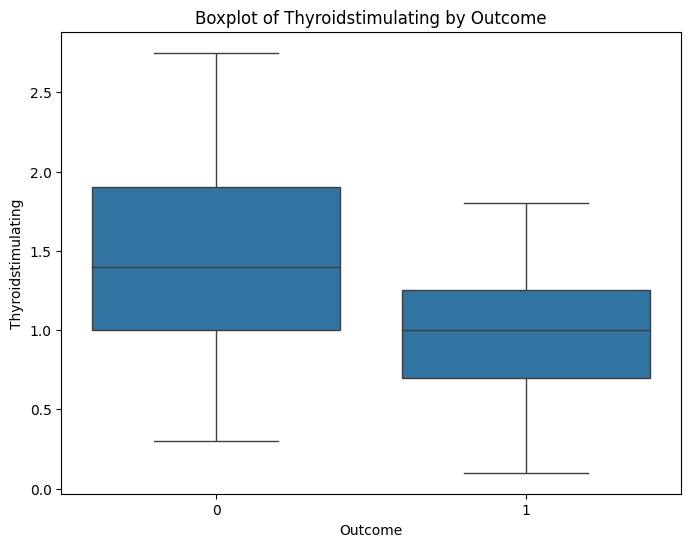

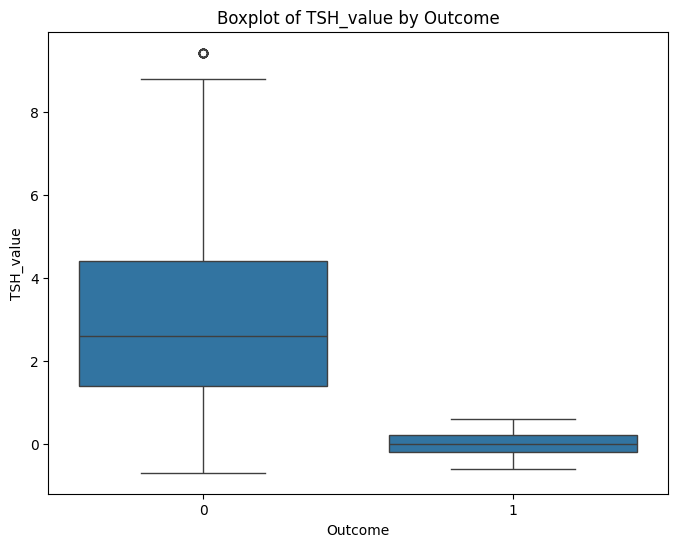

In [157]:
cols = [col for col in dataframe.columns if col!="Outcome"]
for col in cols:
        plt.figure(figsize=(8, 6))
        sns.boxplot(data=dataframe, x="Outcome", y=col)
        plt.title(f'Boxplot of {col} by Outcome')
        plt.show()

### save the preprocessed dataset as csv

In [158]:
dataframe.head()

,T3resin,Thyroxin,Triiodothyronine,Thyroidstimulating,TSH_value,Outcome
0,105.00,7.3,1.500,1.5,-0.1,0
1,81.25,17.6,3.475,1.8,-0.6,1
2,111.00,8.4,1.500,0.8,1.2,0
3,89.00,14.3,3.475,0.5,0.2,1
4,105.00,9.5,1.800,1.6,3.6,0


In [159]:
dataframe.to_csv(path_or_buf="NewThyroid1_processed.csv")